# Explore here

In [ ]:
# Importo todo lo necesario
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score



ds = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv", sep =",")

ds


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [115]:
ds.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [116]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


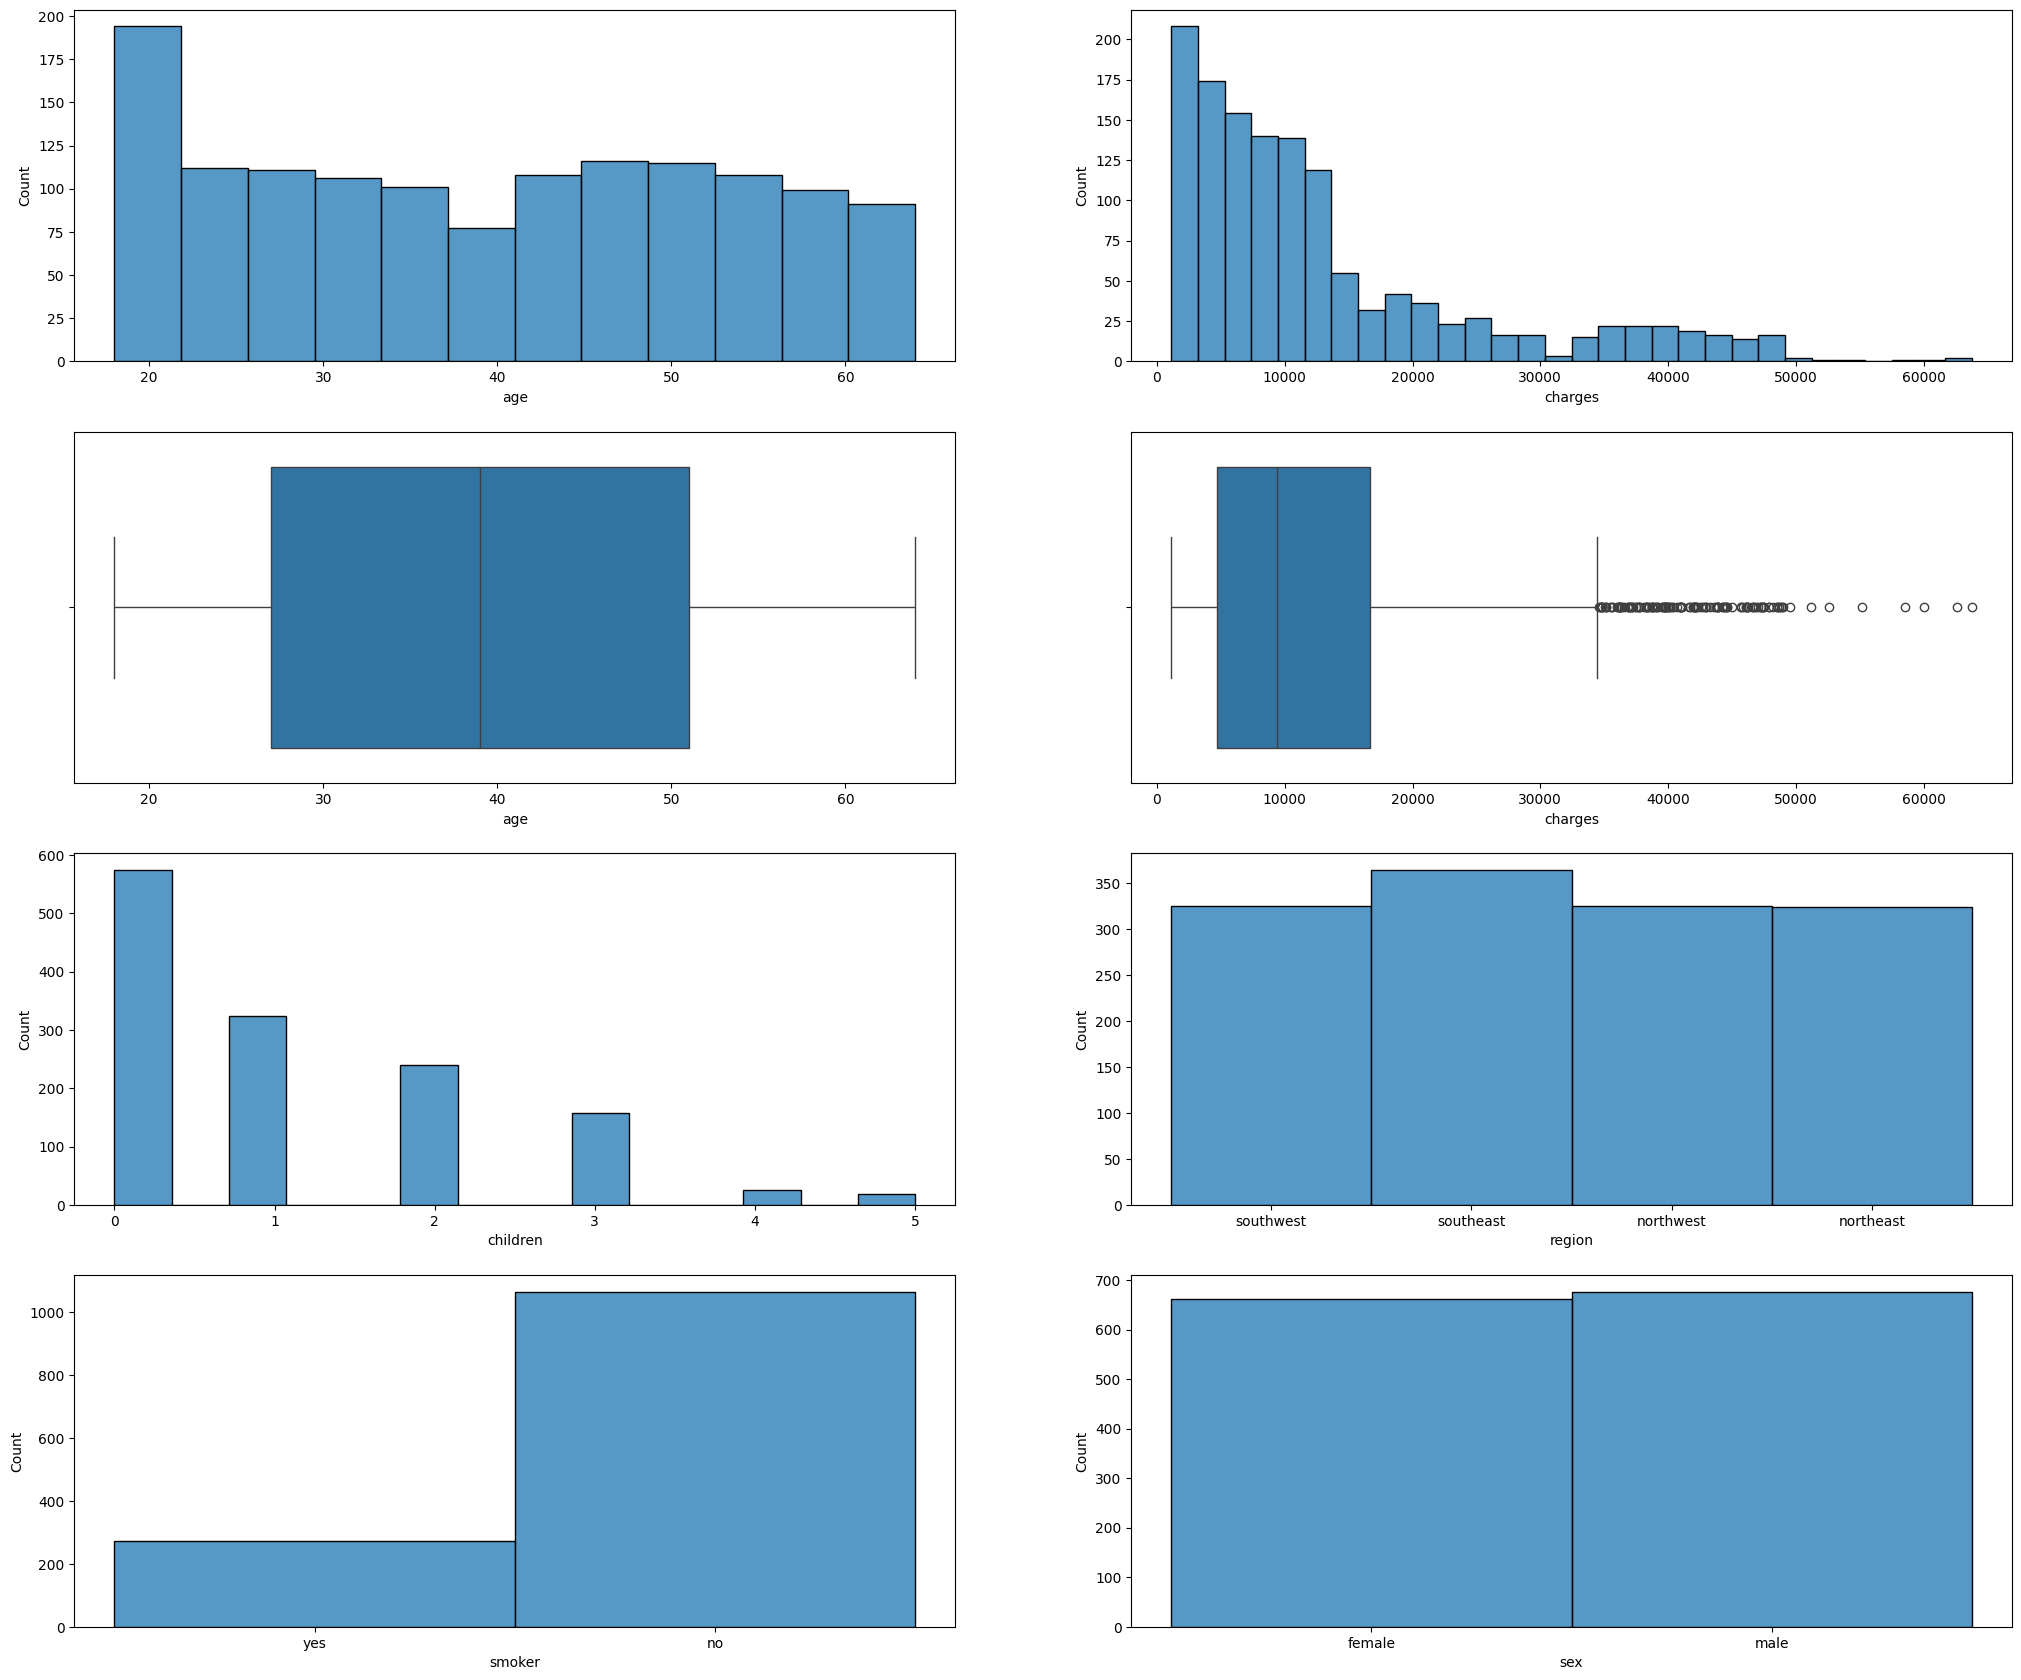

In [117]:
# Grafico

fig, axis  = plt.subplots(4, 2, figsize = (25,21))

sns.histplot(ax = axis [0, 0], data = ds, x = "age")
sns.boxplot(ax = axis [1, 0], data = ds, x = "age")
sns.histplot(ax = axis [0, 1], data = ds, x = "charges")
sns.histplot(ax = axis [2, 0], data = ds, x = "children")
sns.boxplot(ax = axis [1, 1], data = ds, x = "charges")
sns.histplot(ax = axis [2, 1], data = ds, x = "region")
sns.histplot(ax = axis [3, 0], data = ds, x = "smoker")
sns.histplot(ax = axis [3, 1], data = ds, x = "sex")

plt.show()

In [118]:
# Hago un label encoder para poder hacer el heatmap de correlacion. Creo una nueva variable ds_label_encoded para poder usarla solo para el heatmap de correlacion

columnas_categoricas = ds.select_dtypes(include= ["object"]).columns

ds_label_coded = ds.copy()

le = LabelEncoder()

ds_label_coded[columnas_categoricas] = ds_label_coded[columnas_categoricas].apply(le.fit_transform)

ds_label_coded

C:\Users\trimb\AppData\Local\Temp\ipykernel_9436\1556588730.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = ds.select_dtypes(include= ["object"]).columns


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


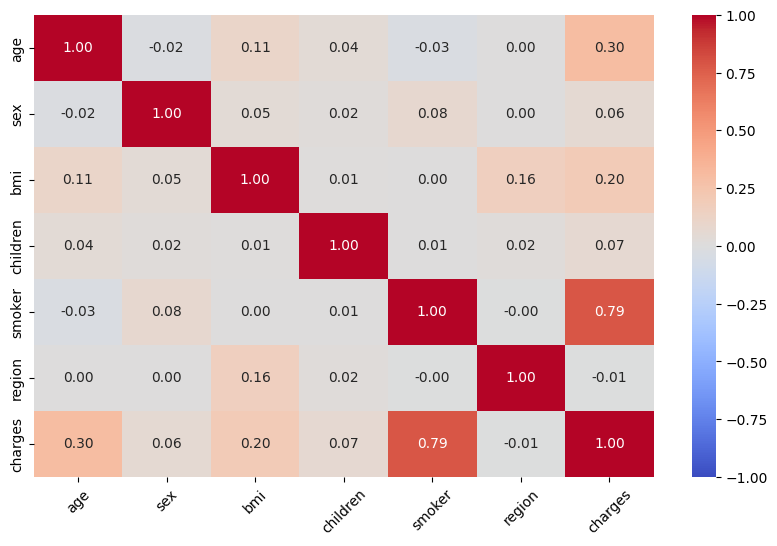

In [119]:
# Heatmap de correlacion

corr = ds_label_coded.corr()

plt.figure(figsize=(10, 6))


sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.tick_params(axis = "x", rotation = 45)
plt.show()


In [ ]:
#One hot encoder de las variables categoricas

encoder = OneHotEncoder(sparse_output = False)

one_hot_encoded = encoder.fit_transform(ds[['region']])

one_hot_ds = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(['region']))

ds.reset_index(drop = True, inplace = True)

def concatenacion():
    global ds
    if'region_northeast' not in ds:
        ds = pd.concat([ds, one_hot_ds], axis = 1)
    ds['sex'] = ds['sex'].map({'male': 1, 'female': 0})
    ds['smoker'] = ds['smoker'].map({'yes': 1, 'no': 0})
    return ds
concatenacion()

ds

,age,sex,bmi,children,smoker,region,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,southwest,16884.92400,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,southeast,1725.55230,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,southeast,4449.46200,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,northwest,21984.47061,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,northwest,3866.85520,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830,0.0,1.0,0.0,0.0
1334,18,0,31.920,0,0,northeast,2205.98080,1.0,0.0,0.0,0.0
1335,18,0,36.850,0,0,southeast,1629.83350,0.0,0.0,1.0,0.0
1336,21,0,25.800,0,0,southwest,2007.94500,0.0,0.0,0.0,1.0


In [121]:
ds.drop(['region'], axis = 1, inplace = True)

ds

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0.0,1.0,0.0,0.0
1334,18,0,31.920,0,0,2205.98080,1.0,0.0,0.0,0.0
1335,18,0,36.850,0,0,1629.83350,0.0,0.0,1.0,0.0
1336,21,0,25.800,0,0,2007.94500,0.0,0.0,0.0,1.0


In [ ]:
# Aca cree un dataset temporal para ver que caracteristicas tenian los outliers para ver si se quedaban o no. Me sirvio para darme cuenta que tienen sentido los
# precios tan caros porque justo coinciden con que son personas fumadoras y con obesidad, por eso los deje.

ds_filtrado = ds[ds['charges'] > 50000]

ds_filtrado

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
34,28,1,36.400,1,1,51194.55914,0.0,0.0,0.0,1.0
543,54,0,47.410,0,1,63770.42801,0.0,0.0,1.0,0.0
577,31,0,38.095,1,1,58571.07448,1.0,0.0,0.0,0.0
819,33,0,35.530,0,1,55135.40209,0.0,1.0,0.0,0.0
1146,60,1,32.800,0,1,52590.82939,0.0,0.0,0.0,1.0
1230,52,1,34.485,3,1,60021.39897,0.0,1.0,0.0,0.0
1300,45,1,30.360,0,1,62592.87309,0.0,0.0,1.0,0.0


In [ ]:
#Preparo todo para modelar

x = ds.apply(pd.to_numeric, errors = 'coerce').drop(['charges'], axis = 1)
y = ds['charges']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.20, random_state = 42
)

In [ ]:
# Use k="all" porque son muy pocas columnas

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func = f_regression, k = "all"))
])

In [ ]:
#Aplico el pipeline completo al train (imputa nulos, escala y selecciona las mejores features)
X_train_sel = pipe.fit_transform(X_train, y_train)

#Obtengo una mascara True/False indicando que columnas fueron seleccionadas
mask = pipe.named_steps["selector"].get_support()

#Extraemos los nombres de las columnas seleccionadas
selected_cols = np.array(ds.columns.drop(["charges"]))[mask]

#Aplico la misma transformacion al test (sin reaprender, solo transforma)
X_test_sel = pipe.transform(X_test)

In [ ]:
#Transformo ambos a un dataset

X_train_sel = pd.DataFrame(X_train_sel, index = X_train.index, columns = selected_cols)
X_test_sel = pd.DataFrame(X_test_sel, index = X_test.index, columns = selected_cols)

print("Features seleccionadas:", list(selected_cols))

X_train_sel.head()

Features seleccionadas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
560,0.472227,-1.024602,-1.756525,0.734336,-0.508747,-0.576631,1.783168,-0.599661,-0.572314
1285,0.543313,-1.024602,-1.033082,-0.911192,-0.508747,1.734212,-0.560800,-0.599661,-0.572314
1142,0.898745,-1.024602,-0.943687,-0.911192,-0.508747,-0.576631,-0.560800,1.667609,-0.572314
969,-0.025379,-1.024602,0.622393,3.202629,-0.508747,-0.576631,-0.560800,1.667609,-0.572314
486,1.040918,-1.024602,-1.504893,1.557100,-0.508747,-0.576631,1.783168,-0.599661,-0.572314


In [ ]:
#Guardo ambos en local
X_train_sel["charges"] = list(y_train)
X_test_sel["charges"] = list(y_test)

X_train_sel.to_csv("../data/processed/train.csv")
X_test_sel.to_csv("../data/processed/test.csv")

In [128]:
X_train_sel.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,charges
560,0.472227,-1.024602,-1.756525,0.734336,-0.508747,-0.576631,1.783168,-0.599661,-0.572314,9193.83850
1285,0.543313,-1.024602,-1.033082,-0.911192,-0.508747,1.734212,-0.560800,-0.599661,-0.572314,8534.67180
1142,0.898745,-1.024602,-0.943687,-0.911192,-0.508747,-0.576631,-0.560800,1.667609,-0.572314,27117.99378
969,-0.025379,-1.024602,0.622393,3.202629,-0.508747,-0.576631,-0.560800,1.667609,-0.572314,8596.82780
486,1.040918,-1.024602,-1.504893,1.557100,-0.508747,-0.576631,1.783168,-0.599661,-0.572314,12475.35130


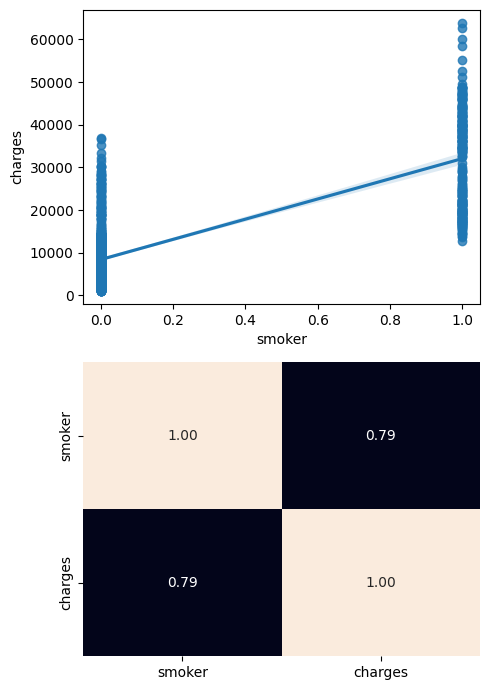

In [ ]:
fig, axis = plt.subplots(2, 1, figsize = (5, 7))
total_data = pd.concat([X_train_sel, X_test_sel])

sns.regplot(ax = axis[0], data = ds, x = "smoker", y = "charges")
sns.heatmap(ds[["smoker", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)

plt.tight_layout()

plt.show()

In [ ]:
#Defino las variables para el modelo

X_train = X_train_sel.drop(["charges"], axis = 1)
X_test = X_test_sel.drop(["charges"], axis = 1)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Calculo error intercepto y coeficientes

print(f"Intercepto (a): {model.intercept_}")
print(f"Coeficientes (b): {model.coef_}")

Intercepto (a): 13346.089736364485
Coeficientes (b): [ 3.61497541e+03 -9.29310107e+00  2.03622812e+03  5.16890247e+02
  9.55848141e+03  1.99698058e+02  3.87349490e+01 -8.66211474e+01
 -1.50167101e+02]


In [133]:
y_pred = model.predict(X_test)
y_pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

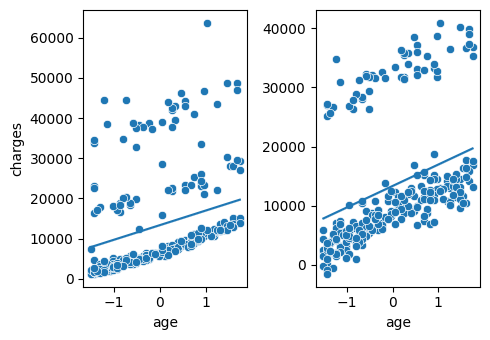

In [134]:
fig, axis = plt.subplots(1, 2, figsize = (5, 3.5))
total_data = pd.concat([X_train, X_test])

# Utilizamos los parámetros ajustados en el entrenamiento para dibujar la línea de regresión en los gráficos
regression_equation = lambda x: 13346.089736364485 + 3.61497541e+03 * x

sns.scatterplot(ax = axis[0], data = X_test, x = "age", y = y_test)
sns.lineplot(ax = axis[0], x = X_test["age"], y = regression_equation(X_test["age"]))
sns.scatterplot(ax = axis[1], x = X_test["age"], y = y_pred)
sns.lineplot(ax = axis[1], x = X_test["age"], y = regression_equation(X_test["age"])).set(ylabel = None)

plt.tight_layout()


In [ ]:
#Calculo error cuadratico medio y coeficiente de determinacion

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 33596915.85136146
Coeficiente de determinación: 0.7835929767120723


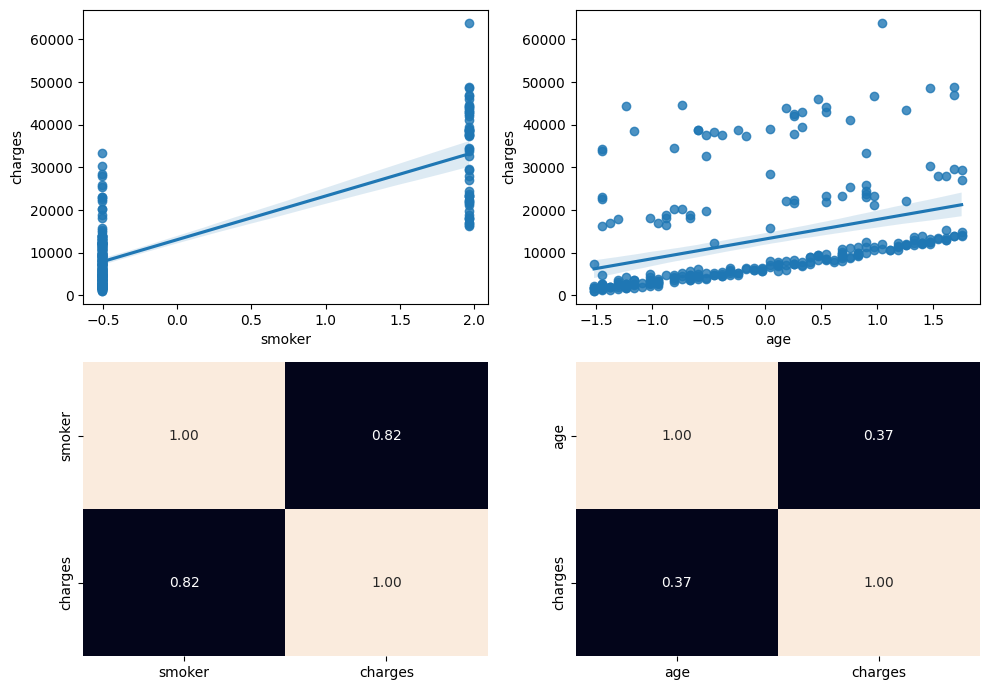

In [ ]:
#Grafico la regresion lineal multiple

test_combined = X_test.copy()
test_combined["charges"] = y_test.values

fig, axis = plt.subplots(2, 2, figsize = (10, 7))
total_data = pd.concat([X_train, X_test])

sns.regplot(ax = axis[0, 0], data = test_combined, x = "smoker", y = "charges")
sns.heatmap(test_combined[["smoker", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = test_combined, x = "age", y = "charges")
sns.heatmap(test_combined[["age", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

plt.tight_layout()

plt.show()

In [ ]:
#Aplico Lasso

lasso_model = Lasso(alpha = 0.1, max_iter = 300)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

y_pred_lasso

array([ 8969.44045797,  7068.72457906, 36857.98853986,  9454.64480634,
       26973.18535308, 10864.31030685,   170.47887742, 16903.35369466,
        1092.7038429 , 11218.24620295, 28101.76043991,  9377.73817614,
        5263.02194778, 38415.50371481, 40255.45130216, 37097.83786381,
       15239.95451224, 35912.35670488,  9112.40116537, 31461.63255782,
        3847.91565662, 10130.33620499,  2371.10016217,  7140.18899655,
       11301.4500433 , 12961.53005721, 14509.47601597,  6159.69222147,
        9963.71463865,  2178.18251026,  9115.84243313, 13073.5055477 ,
        4561.83605653,  3408.13977022,  4460.25518885, 13032.11492939,
        1980.29804299,  8813.39479966, 33270.90860766, 32585.30442995,
        3908.73288394,  4326.2990795 , 14142.75369577, 11423.57686156,
        8774.12902298, 12097.54927339,  5281.43600764,  3150.71395019,
       35494.04091713,  9150.07510295, 15836.56892412,  2343.83351427,
       12364.48675609,  1482.72200147, 13389.07985494, 12573.5512494 ,
      

In [ ]:
#Error y coeficiente de Lasso

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred_lasso)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_lasso)}")

Error cuadrático medio: 33597075.66426044
Coeficiente de determinación: 0.7835919473130077


In [ ]:
#Aplico Ridge

ridge_model = Ridge(alpha = 0.1, max_iter = 300)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

y_pred_ridge

array([ 8969.87990723,  7069.17592543, 36855.92943283,  9455.0789568 ,
       26971.83802421, 10864.41309189,   171.36813869, 16903.06018918,
        1093.45122759, 11218.57969403, 28100.33040351,  9378.1316497 ,
        5263.91309507, 38413.91569101, 40253.40924816, 37096.21191473,
       15240.33672875, 35910.78450958,  9112.98489028, 31459.98065314,
        3848.73799409, 10130.48080406,  2371.6064131 ,  7140.72790009,
       11301.86052541, 12961.55125454, 14509.20760391,  6160.51579347,
        9964.09474821,  2179.12313008,  9116.31643312, 13073.52365091,
        4562.73842291,  3409.05593297,  4460.69920734, 13032.11969119,
        1980.97910995,  8813.59877904, 33269.18966504, 32583.87800358,
        3909.69191608,  4326.98227881, 14142.620478  , 11423.55985347,
        8774.83331005, 12097.38947004,  5282.26159297,  3151.4832133 ,
       35492.60310957,  9150.78008383, 15836.63625513,  2344.85297378,
       12364.76380278,  1483.447671  , 13389.22174043, 12573.70553604,
      

In [ ]:
#Error y coeficiente de Ridge

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred_ridge)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_ridge)}")

Error cuadrático medio: 33597671.99731525
Coeficiente de determinación: 0.7835881061669379
